<a href="https://colab.research.google.com/github/AnnabelleMcSharry/AI-ML-Car-Data/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [196]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [197]:
Employees = pd.read_csv("Employers_data.csv")
Employees.head()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


In [198]:
print(Employees.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  object
 4   Department        10000 non-null  object
 5   Job_Title         10000 non-null  object
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  object
 8   Location          10000 non-null  object
 9   Salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB
None


In [199]:
Employees.isnull().sum()

,0
Employee_ID,0
Name,0
Age,0
Gender,0
Department,0
Job_Title,0
Experience_Years,0
Education_Level,0
Location,0
Salary,0


In [200]:
Employees = Employees.drop(["Employee_ID"], axis=1)
Employees = Employees.drop(["Age"], axis=1)
Employees = Employees.drop(["Gender"], axis=1)
Employees = Employees.drop(["Name"], axis=1)
print(Employees.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Department        10000 non-null  object
 1   Job_Title         10000 non-null  object
 2   Experience_Years  10000 non-null  int64 
 3   Education_Level   10000 non-null  object
 4   Location          10000 non-null  object
 5   Salary            10000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 468.9+ KB
None


In [201]:
Employees.describe()

,Experience_Years,Salary
count,10000.000000,10000.000000
mean,12.370900,115381.500000
std,9.148951,46066.139047
min,0.000000,25000.000000
25%,5.000000,70000.000000
50%,10.000000,120000.000000
75%,19.000000,150000.000000
max,37.000000,215000.000000


In [202]:
print("Unique values in Department:\n", Employees['Department'].value_counts())
print("\nUnique values in Job_Title:\n", Employees['Job_Title'].value_counts())
print("\nUnique values in Education_Level:\n", Employees['Education_Level'].value_counts())
print("\nUnique values in Location:\n", Employees['Location'].value_counts())

Unique values in Department:
 Department
Product        1724
Engineering    1683
Sales          1669
Marketing      1669
HR             1660
Finance        1595
Name: count, dtype: int64

Unique values in Job_Title:
 Job_Title
Manager      3325
Analyst      2799
Executive    1921
Engineer     1375
Intern        580
Name: count, dtype: int64

Unique values in Education_Level:
 Education_Level
Master      4930
Bachelor    3381
PhD         1689
Name: count, dtype: int64

Unique values in Location:
 Location
Austin           2034
Seattle          2017
Chicago          2008
New York         1980
San Francisco    1961
Name: count, dtype: int64


In [203]:
Employees_encoded = pd.get_dummies(Employees, columns=['Department'], drop_first=False)
print(Employees_encoded.head())

   Job_Title  Experience_Years Education_Level  Location  Salary  \
0   Engineer                 1          Master    Austin   90000   
1  Executive                33          Master   Seattle  195000   
2     Intern                 1        Bachelor  New York   35000   
3    Analyst                 9        Bachelor  New York   75000   
4    Analyst                 2          Master   Seattle   70000   

   Department_Engineering  Department_Finance  Department_HR  \
0                    True               False          False   
1                   False               False          False   
2                    True               False          False   
3                   False                True          False   
4                   False               False           True   

   Department_Marketing  Department_Product  Department_Sales  
0                 False               False             False  
1                 False               False              True  
2             

In [204]:
Employees_encoded = pd.get_dummies(Employees_encoded, columns=['Location'], drop_first=False)
print(Employees_encoded.head())

   Job_Title  Experience_Years Education_Level  Salary  \
0   Engineer                 1          Master   90000   
1  Executive                33          Master  195000   
2     Intern                 1        Bachelor   35000   
3    Analyst                 9        Bachelor   75000   
4    Analyst                 2          Master   70000   

   Department_Engineering  Department_Finance  Department_HR  \
0                    True               False          False   
1                   False               False          False   
2                    True               False          False   
3                   False                True          False   
4                   False               False           True   

   Department_Marketing  Department_Product  Department_Sales  \
0                 False               False             False   
1                 False               False              True   
2                 False               False             False   
3     

In [205]:
education_order = {'Bachelor': 0, 'Master': 1, 'PhD': 2}
Employees_encoded['Education_Level_Encoded'] = Employees_encoded['Education_Level'].map(education_order)
Employees_encoded = Employees_encoded.drop('Education_Level', axis=1)
print(Employees_encoded.head())

   Job_Title  Experience_Years  Salary  Department_Engineering  \
0   Engineer                 1   90000                    True   
1  Executive                33  195000                   False   
2     Intern                 1   35000                    True   
3    Analyst                 9   75000                   False   
4    Analyst                 2   70000                   False   

   Department_Finance  Department_HR  Department_Marketing  \
0               False          False                 False   
1               False          False                 False   
2               False          False                 False   
3                True          False                 False   
4               False           True                 False   

   Department_Product  Department_Sales  Location_Austin  Location_Chicago  \
0               False             False             True             False   
1               False              True            False             False

In [206]:
job_title_order = {'Intern': 0, 'Analyst': 1, 'Engineer': 2, 'Manager': 3, 'Executive': 4}
Employees_encoded['Job_Title_Encoded'] = Employees_encoded['Job_Title'].map(job_title_order)
Employees_encoded = Employees_encoded.drop('Job_Title', axis=1)
print(Employees_encoded.head())

   Experience_Years  Salary  Department_Engineering  Department_Finance  \
0                 1   90000                    True               False   
1                33  195000                   False               False   
2                 1   35000                    True               False   
3                 9   75000                   False                True   
4                 2   70000                   False               False   

   Department_HR  Department_Marketing  Department_Product  Department_Sales  \
0          False                 False               False             False   
1          False                 False               False              True   
2          False                 False               False             False   
3          False                 False               False             False   
4           True                 False               False             False   

   Location_Austin  Location_Chicago  Location_New York  \
0        

In [207]:
print(Employees_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Experience_Years         10000 non-null  int64
 1   Salary                   10000 non-null  int64
 2   Department_Engineering   10000 non-null  bool 
 3   Department_Finance       10000 non-null  bool 
 4   Department_HR            10000 non-null  bool 
 5   Department_Marketing     10000 non-null  bool 
 6   Department_Product       10000 non-null  bool 
 7   Department_Sales         10000 non-null  bool 
 8   Location_Austin          10000 non-null  bool 
 9   Location_Chicago         10000 non-null  bool 
 10  Location_New York        10000 non-null  bool 
 11  Location_San Francisco   10000 non-null  bool 
 12  Location_Seattle         10000 non-null  bool 
 13  Education_Level_Encoded  10000 non-null  int64
 14  Job_Title_Encoded        10000 non-null  int64
dtypes: 

In [208]:
Employees_encoded.describe()

,Experience_Years,Salary,Education_Level_Encoded,Job_Title_Encoded
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,12.370900,115381.500000,0.830800,2.320800
std,9.148951,46066.139047,0.691679,1.228836
min,0.000000,25000.000000,0.000000,0.000000
25%,5.000000,70000.000000,0.000000,1.000000
50%,10.000000,120000.000000,1.000000,3.000000
75%,19.000000,150000.000000,1.000000,3.000000
max,37.000000,215000.000000,2.000000,4.000000


### Justifying Scaling: Visualizing Feature Distributions

To understand why scaling is important, let's visualize the distribution and range of our numerical features: `Experience_Years`, `Salary`, `Education_Level_Encoded`, and `Job_Title_Encoded`. This will clearly show the differences in their scales.

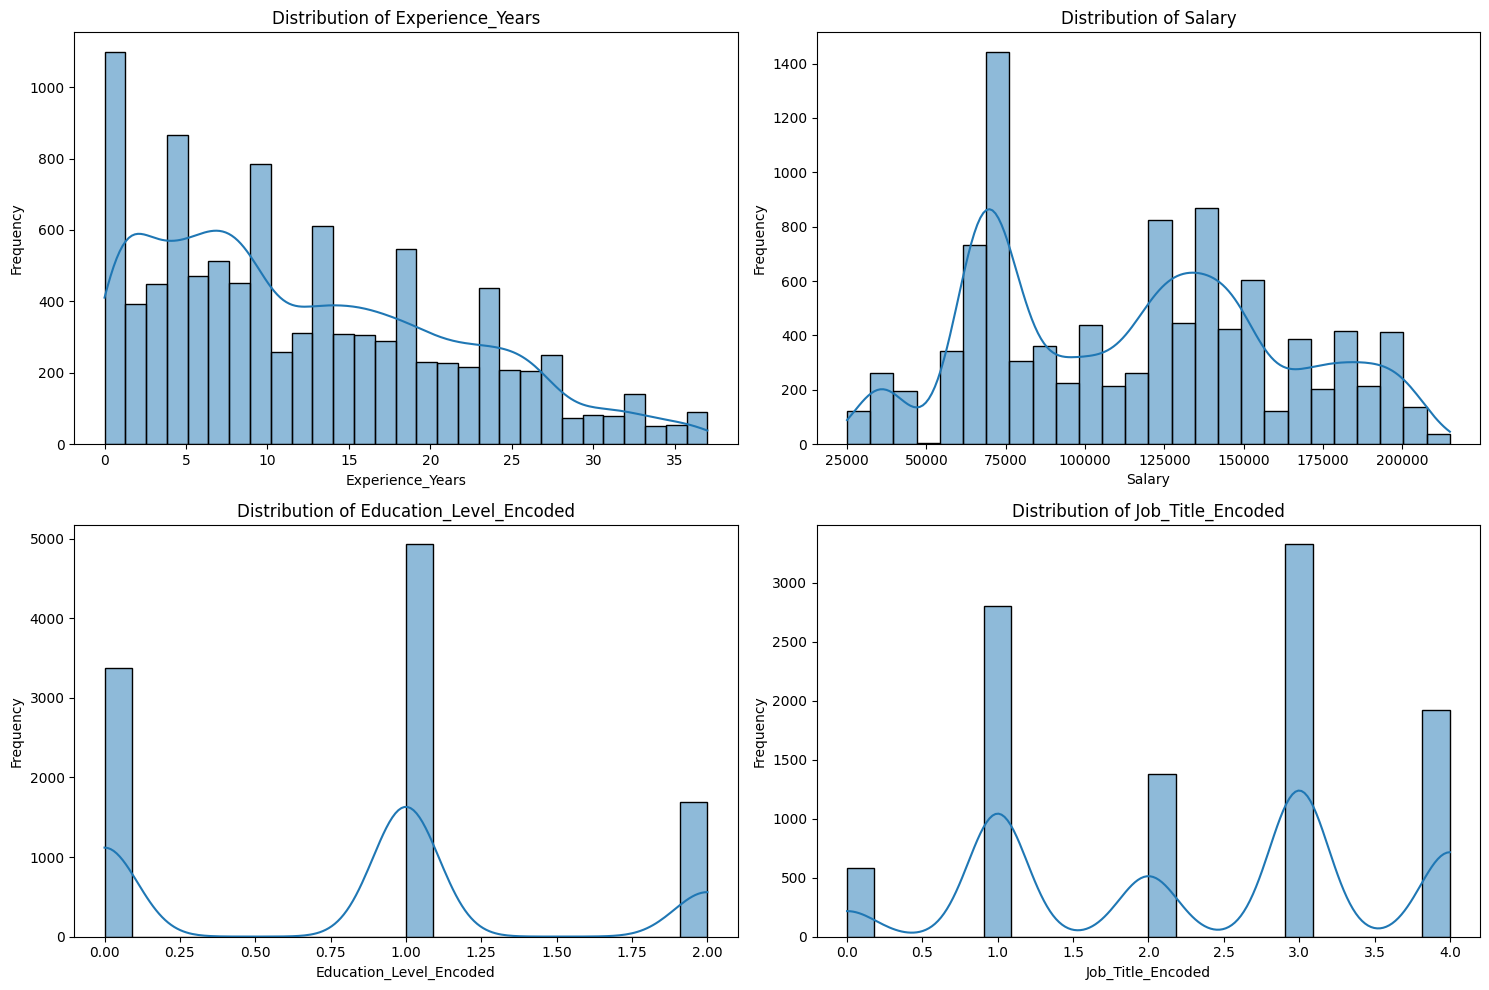

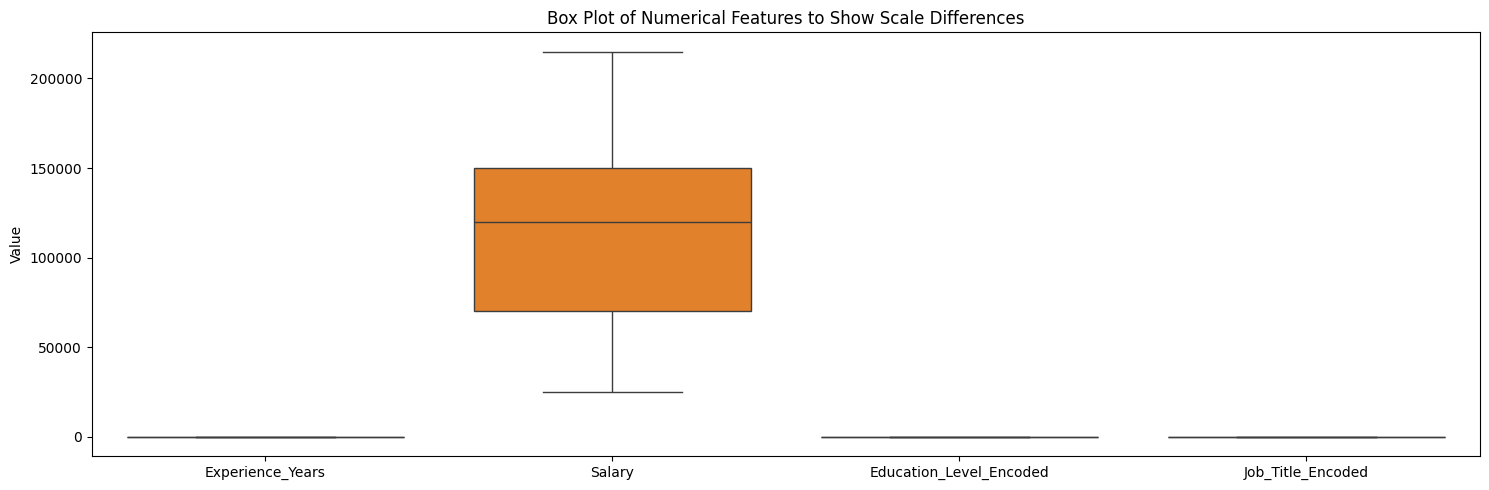

In [209]:
numerical_cols = ['Experience_Years', 'Salary', 'Education_Level_Encoded', 'Job_Title_Encoded']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of subplots
    sns.histplot(Employees_encoded[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
sns.boxplot(data=Employees_encoded[numerical_cols])
plt.title('Box Plot of Numerical Features to Show Scale Differences')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

As you can see from the histograms and especially the box plot, `Salary` has a much larger range and scale compared to `Experience_Years`, `Education_Level_Encoded`, and `Job_Title_Encoded`. If we use these features directly in distance-based clustering algorithms (like K-Means), the `Salary` feature would dominate the distance calculations, making the other features less influential.

**Conclusion for Scaling:** Scaling is essential to ensure that all features contribute equally to the distance metric, preventing features with larger numerical ranges from disproportionately influencing the clustering results.

### Justifying Outlier Analysis: Visual and Quantitative Checks

While descriptive statistics provide a hint, visual and quantitative methods are better for identifying outliers. Let's use box plots and the Interquartile Range (IQR) method.

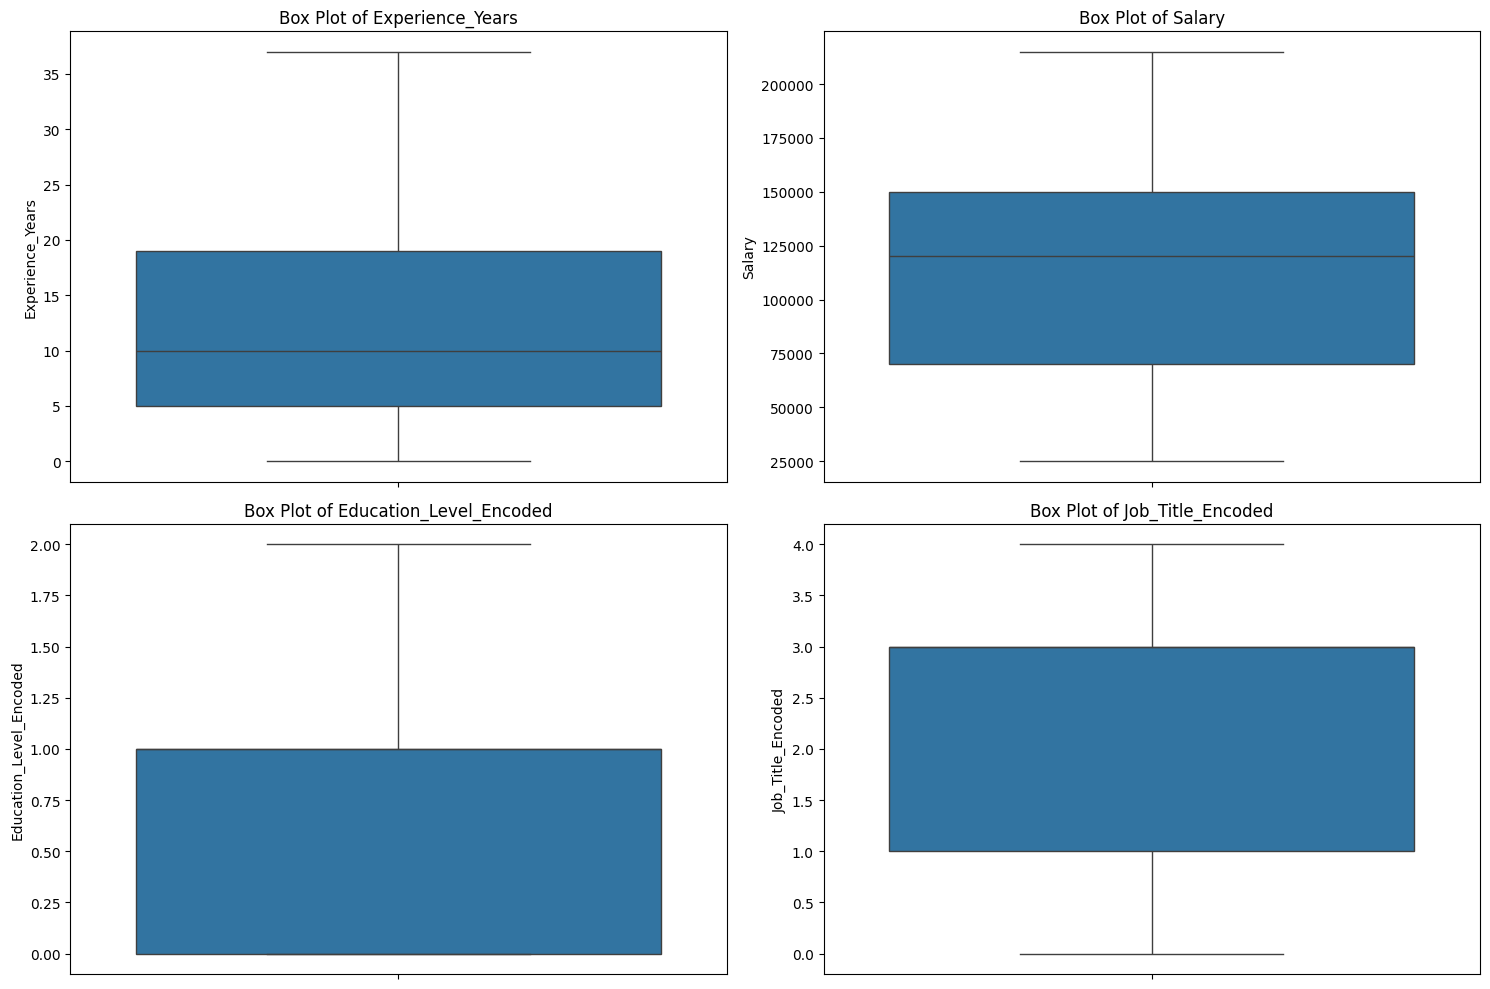

In [210]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=Employees_encoded[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

The box plots visually indicate some potential outliers, particularly in `Experience_Years` and `Salary`. Now, let's use the IQR method to quantitatively identify outliers for these columns.

In [211]:
for col in ['Experience_Years', 'Salary']:
    Q1 = Employees_encoded[col].quantile(0.25)
    Q3 = Employees_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = Employees_encoded[(Employees_encoded[col] < lower_bound) | (Employees_encoded[col] > upper_bound)]
    print(f"Number of outliers in '{col}': {len(outliers)}")
    if len(outliers) > 0:
        print(f"\tExamples of outliers in '{col}':")
        print(outliers[[col]].head())

# You can now decide whether to remove, transform, or keep these outliers based on your domain knowledge and the goals of your clustering.

Number of outliers in 'Experience_Years': 0
Number of outliers in 'Salary': 0


In [212]:
Employees = Employees.drop_duplicates()
print(Employees.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5192 entries, 0 to 9997
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Department        5192 non-null   object
 1   Job_Title         5192 non-null   object
 2   Experience_Years  5192 non-null   int64 
 3   Education_Level   5192 non-null   object
 4   Location          5192 non-null   object
 5   Salary            5192 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 283.9+ KB
None


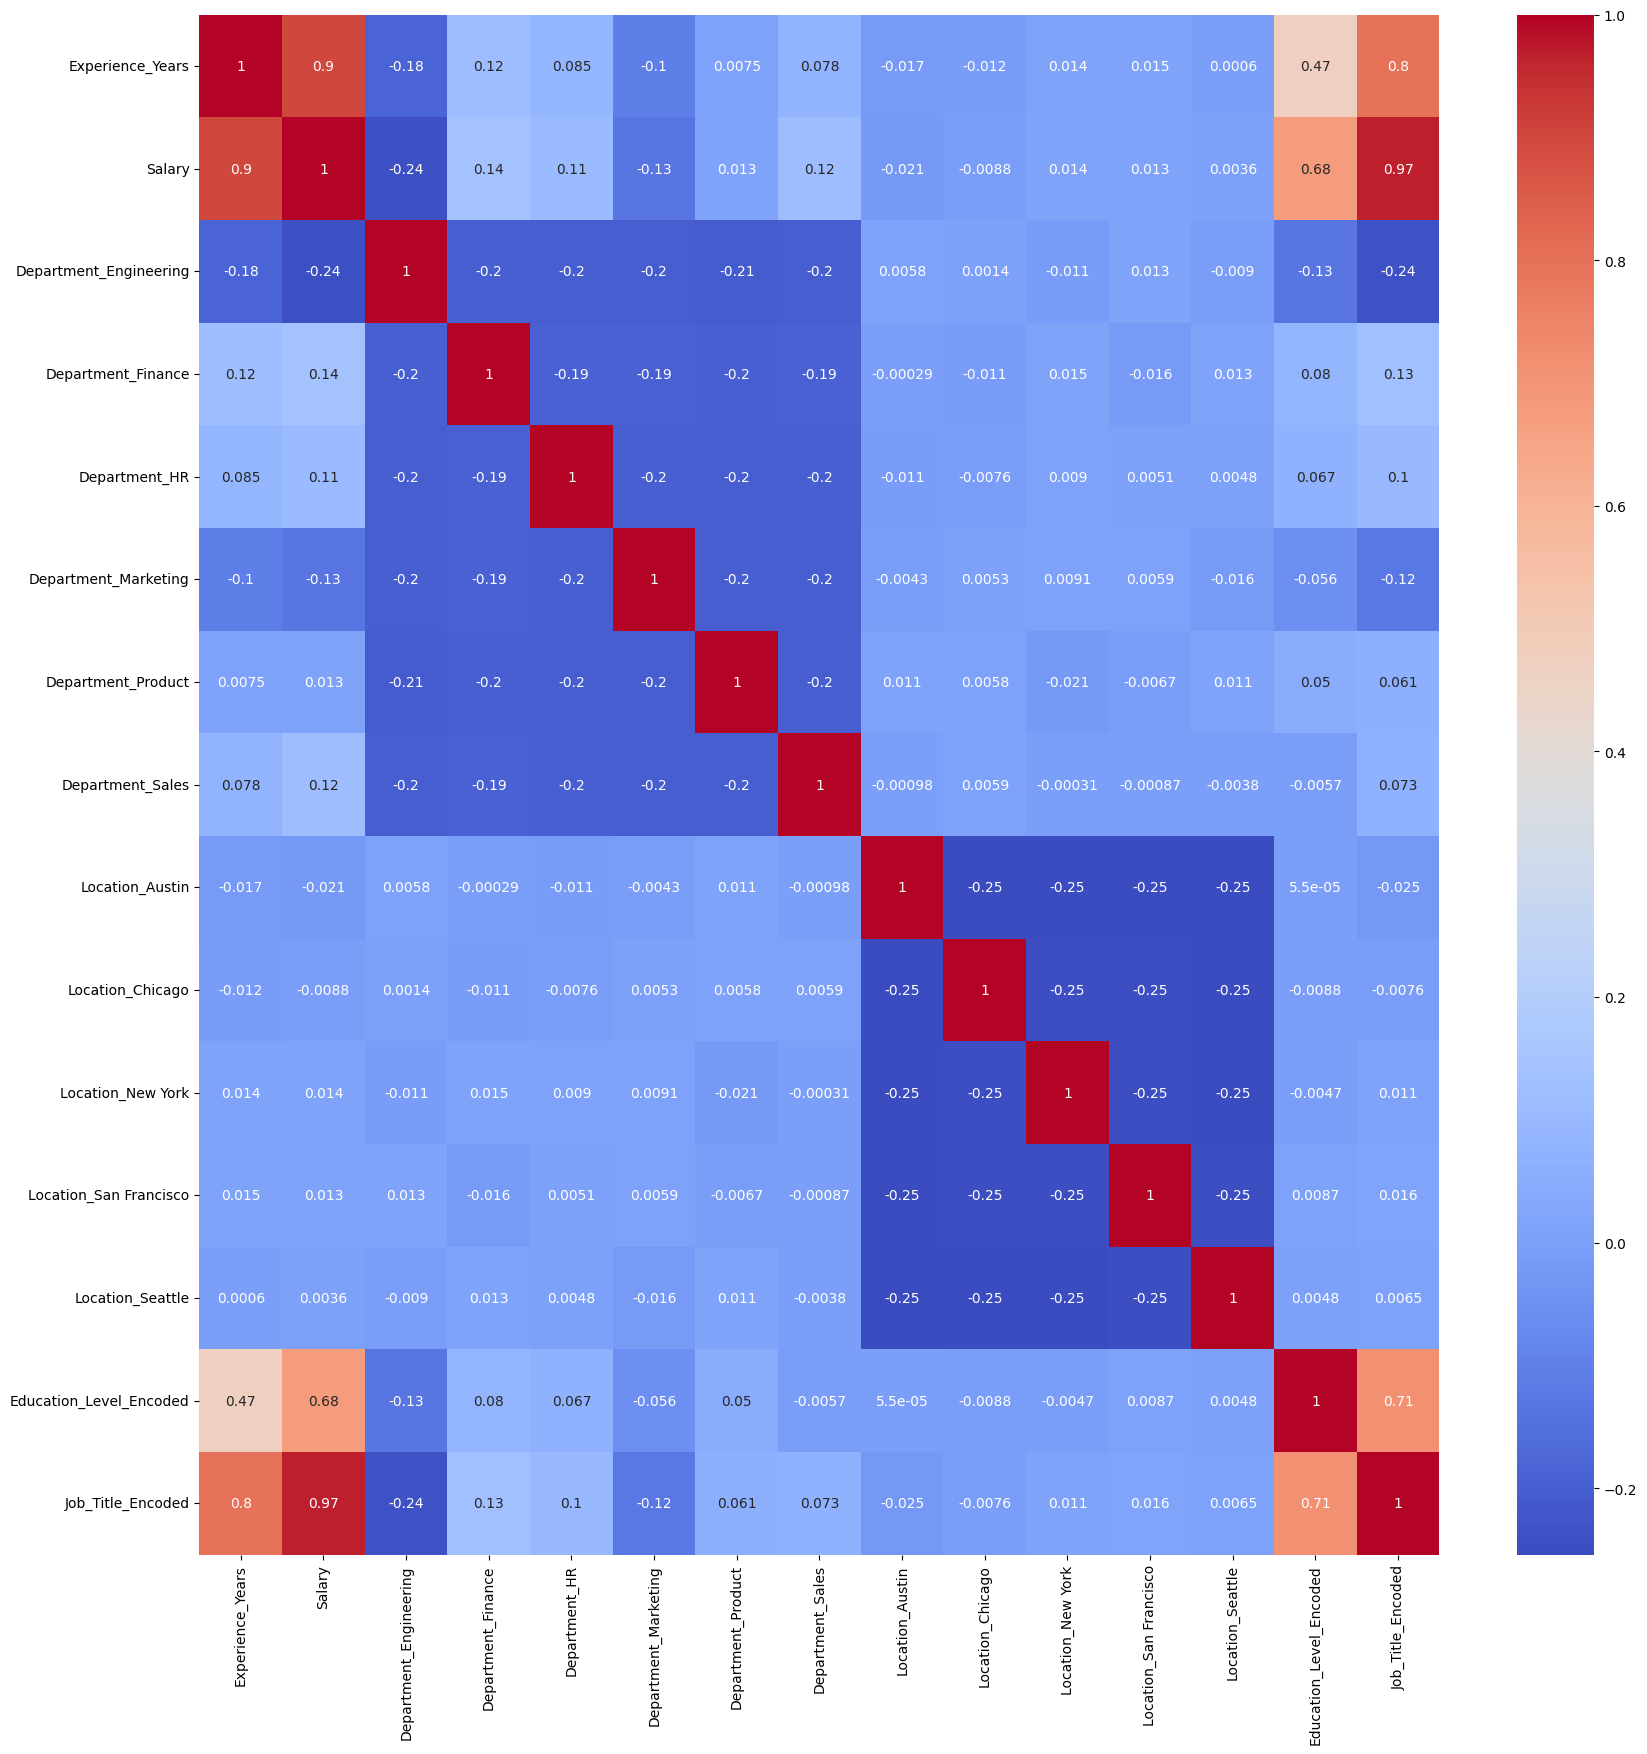

In [213]:
plt.figure(figsize= (20,20))
sns.heatmap(Employees_encoded.corr(), annot = True, cmap= "coolwarm")
plt.show()

In [214]:
location_cols = [col for col in Employees_encoded.columns if 'Location_' in col]
Employees_encoded = Employees_encoded.drop(columns=location_cols)
print("DataFrame after dropping Location columns:")
display(Employees_encoded.head())

#got rid of location as there is close to 0 correlation all around
#wanted to see if all leadership worked in a single office but can see it has very low corelation with salary/ job title/ experience years or education

DataFrame after dropping Location columns:


,Experience_Years,Salary,Department_Engineering,Department_Finance,Department_HR,Department_Marketing,Department_Product,Department_Sales,Education_Level_Encoded,Job_Title_Encoded
0,1,90000,True,False,False,False,False,False,1,2
1,33,195000,False,False,False,False,False,True,1,4
2,1,35000,True,False,False,False,False,False,0,0
3,9,75000,False,True,False,False,False,False,0,1
4,2,70000,False,False,True,False,False,False,1,1


In [215]:
Employees_encoded = Employees_encoded.drop_duplicates().reset_index(drop=True)
print(Employees_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1948 entries, 0 to 1947
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Experience_Years         1948 non-null   int64
 1   Salary                   1948 non-null   int64
 2   Department_Engineering   1948 non-null   bool 
 3   Department_Finance       1948 non-null   bool 
 4   Department_HR            1948 non-null   bool 
 5   Department_Marketing     1948 non-null   bool 
 6   Department_Product       1948 non-null   bool 
 7   Department_Sales         1948 non-null   bool 
 8   Education_Level_Encoded  1948 non-null   int64
 9   Job_Title_Encoded        1948 non-null   int64
dtypes: bool(6), int64(4)
memory usage: 72.4 KB
None


In [216]:
from sklearn.preprocessing import StandardScaler

# Identify all columns to be scaled. Since boolean columns are effectively 0s and 1s,
# scaling all columns is appropriate for distance-based algorithms.
features_to_scale = Employees_encoded.columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the selected features
Employees_scaled = pd.DataFrame(scaler.fit_transform(Employees_encoded[features_to_scale]), columns=features_to_scale)

# Display the first few rows of the scaled data
print(Employees_scaled.head())

# Display descriptive statistics of the scaled data to verify
print(Employees_scaled.describe())

   Experience_Years    Salary  Department_Engineering  Department_Finance  \
0         -1.519192 -1.012007                2.259775           -0.501924   
1          2.105286  1.550933               -0.442522           -0.501924   
2         -1.519192 -2.354499                2.259775           -0.501924   
3         -0.613073 -1.378141               -0.442522            1.992332   
4         -1.405927 -1.500186               -0.442522           -0.501924   

   Department_HR  Department_Marketing  Department_Product  Department_Sales  \
0      -0.497111             -0.365892           -0.470443         -0.399404   
1      -0.497111             -0.365892           -0.470443          2.503729   
2      -0.497111             -0.365892           -0.470443         -0.399404   
3      -0.497111             -0.365892           -0.470443         -0.399404   
4       2.011624             -0.365892           -0.470443         -0.399404   

   Education_Level_Encoded  Job_Title_Encoded  
0       

In [217]:
from sklearn.decomposition import PCA

# Apply PCA with 2 components
pca_2_components = PCA(n_components=2)
Employees_pca_2d = pca_2_components.fit_transform(Employees_scaled)

# Create a DataFrame for the 2 principal components
Employees_pca_2d_df = pd.DataFrame(Employees_pca_2d, columns=['PC1', 'PC2'])

print(f"Explained variance ratio with 2 components: {pca_2_components.explained_variance_ratio_.sum():.4f}")
display(Employees_pca_2d_df.head())

Explained variance ratio with 2 components: 0.4430


,PC1,PC2
0,-2.138467,0.019898
1,2.767795,0.004504
2,-4.372708,0.065492
3,-2.210614,1.805654
4,-2.194131,-1.769211


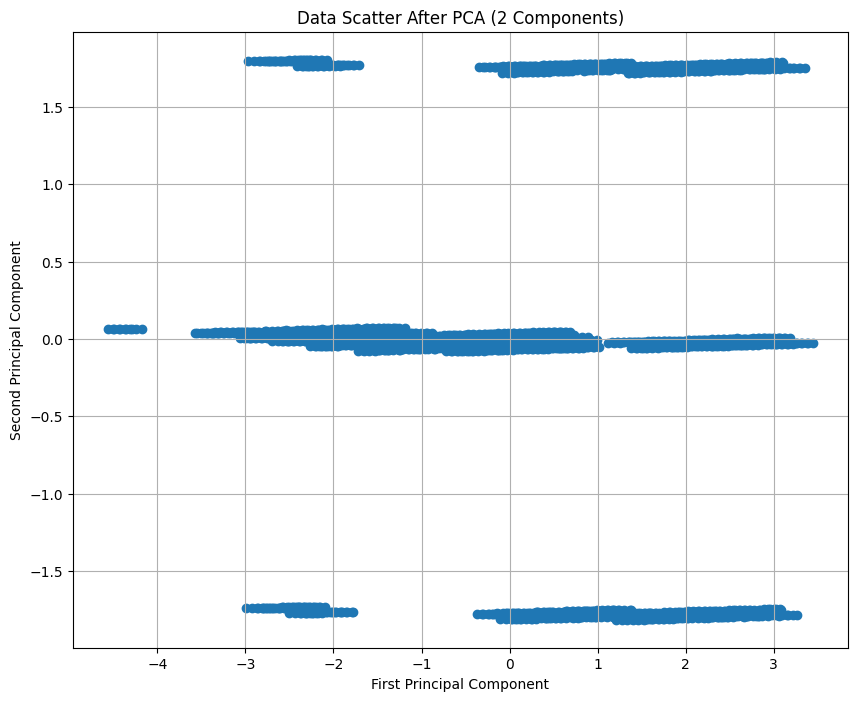

In [218]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(Employees_pca_2d_df['PC1'], Employees_pca_2d_df['PC2'])
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title(f"Data Scatter After PCA (2 Components)")
plt.grid(True)
plt.show()

Explained variance ratio with 2 components (no department): 0.9428


,PC1,PC2
0,-1.826772,0.659633
1,2.487080,-1.428711
2,-4.185695,-0.445337
3,-2.648018,-1.005037
4,-2.585198,0.654345


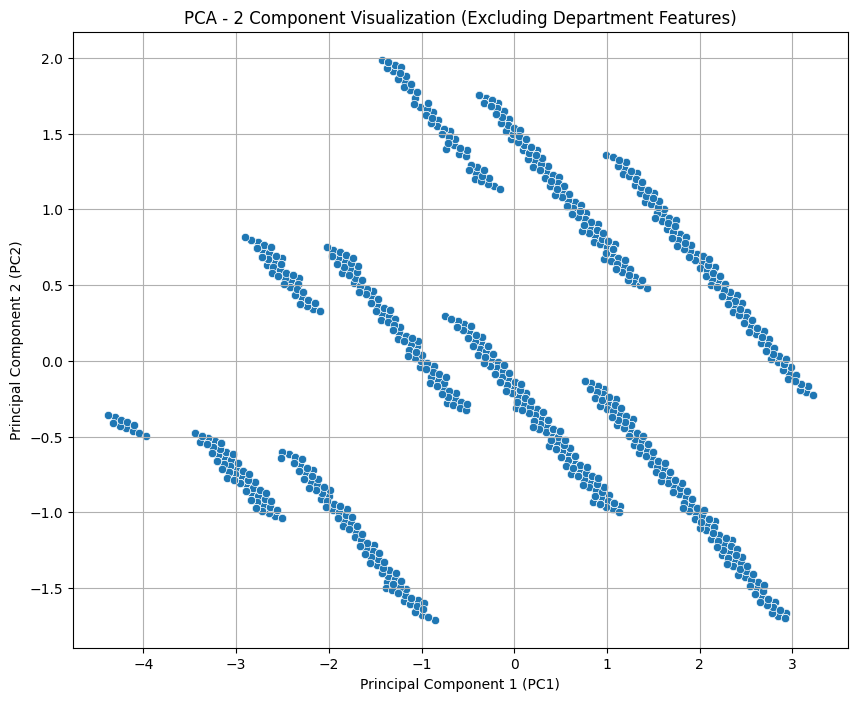

In [219]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Identify 'Department' columns to drop from the Employees_encoded DataFrame
department_cols = [col for col in Employees_encoded.columns if 'Department_' in col]

# Create a new DataFrame without department features (and without location as it was already dropped)
Employees_no_dept = Employees_encoded.drop(columns=department_cols)

# Scale the new DataFrame
scaler_no_dept = StandardScaler()
Employees_no_dept_scaled = pd.DataFrame(scaler_no_dept.fit_transform(Employees_no_dept),
                                          columns=Employees_no_dept.columns)

# Apply PCA with 2 components to the data without department features
pca_2_components_no_dept = PCA(n_components=2)
Employees_pca_2d_no_dept = pca_2_components_no_dept.fit_transform(Employees_no_dept_scaled)

# Create a DataFrame for the 2 principal components
Employees_pca_2d_no_dept_df = pd.DataFrame(Employees_pca_2d_no_dept, columns=['PC1', 'PC2'])

print(f"Explained variance ratio with 2 components (no department): {pca_2_components_no_dept.explained_variance_ratio_.sum():.4f}")
display(Employees_pca_2d_no_dept_df.head())

# Plotting the 2D PCA results
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=Employees_pca_2d_no_dept_df, legend='full')
plt.title('PCA - 2 Component Visualization (Excluding Department Features)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)
plt.show()

### Determining the Optimal Number of Clusters (K) using the Elbow Method

To find the appropriate number of clusters for K-Means, we'll use the Elbow Method. This method involves running K-Means for a range of 'k' values (number of clusters) and calculating the sum of squared distances (SSE) between data points and their assigned cluster centers. The 'elbow' point in the plot of SSE versus 'k' indicates a point where the decrease in SSE begins to slow down, suggesting an optimal 'k'.

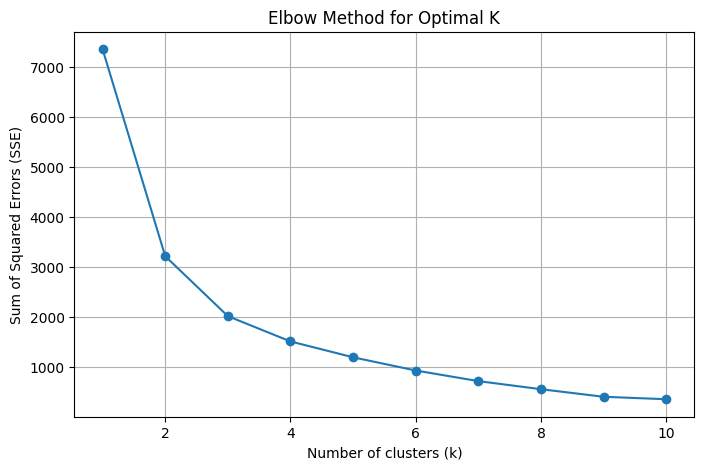

In [220]:
from sklearn.cluster import KMeans

df_for_kmeans = Employees_pca_2d_no_dept_df.copy()

sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_for_kmeans)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

From the Elbow Method plot, we observe that the 'elbow' point appears to be around k=3. We will proceed with **k=3** for K-Means clustering, as it represents a reasonable trade-off between minimizing SSE and keeping the number of clusters manageable for interpretation.

### Applying K-Means Clustering

Now, we will apply K-Means clustering with the chosen optimal number of clusters (k=3) to the 2D PCA-reduced data, using the K-Means code you provided.

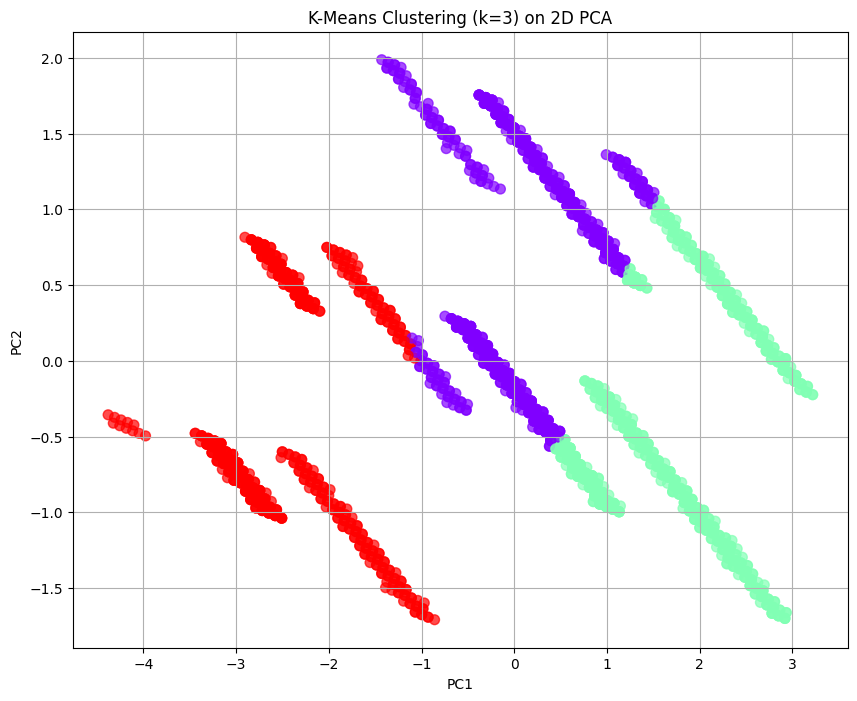

,PC1,PC2,Cluster
0,-1.826772,0.659633,2
1,2.487080,-1.428711,1
2,-4.185695,-0.445337,2
3,-2.648018,-1.005037,2
4,-2.585198,0.654345,2


In [221]:
optimal_k = 3 # Based on the Elbow Method plot and user's request

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Fit K-Means to the PCA-reduced data and get cluster labels
cluster_labels = kmeans.fit_predict(Employees_pca_2d_no_dept_df)

# Add the cluster labels to our PCA DataFrame
Employees_pca_2d_no_dept_df['Cluster'] = cluster_labels

# Plot the clusters as requested by the user
plt.figure(figsize=(10, 8))
plt.scatter(Employees_pca_2d_no_dept_df['PC1'], Employees_pca_2d_no_dept_df['PC2'],
            c=Employees_pca_2d_no_dept_df['Cluster'], cmap='rainbow', s=50, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means Clustering (k={optimal_k}) on 2D PCA')
plt.grid(True)
plt.show()

# Display the first few rows with cluster labels
display(Employees_pca_2d_no_dept_df.head())

### Applying DBSCAN Clustering

Unlike K-Means, DBSCAN (Density-Based Spatial Clustering of Applications with Noise) does not require a pre-defined number of clusters. Instead, it groups together data points that are closely packed together, marking as outliers points that lie alone in low-density regions. We will use the parameters you provided: `eps=0.7` and `min_samples=10`.

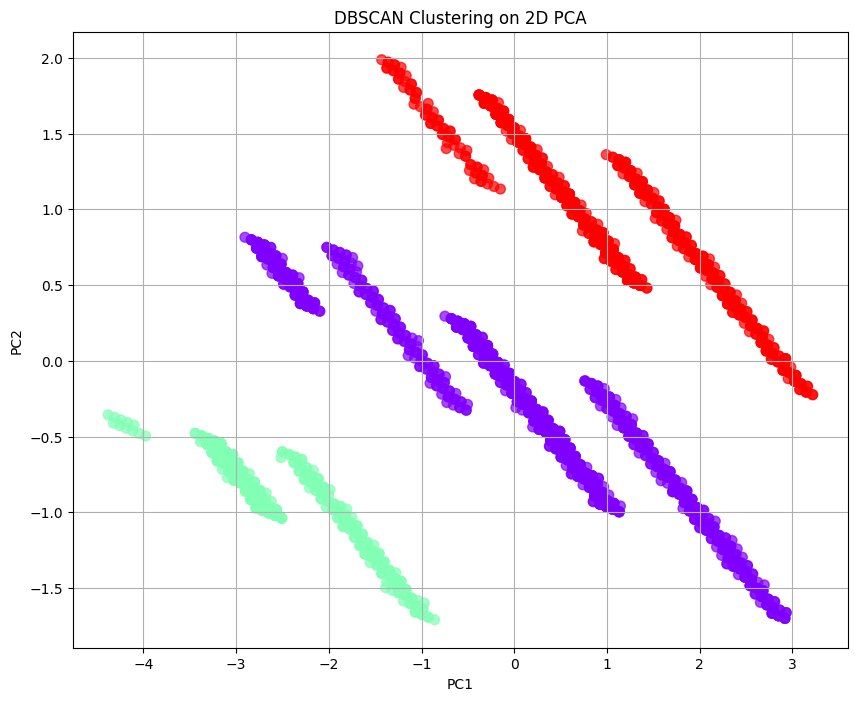

,PC1,PC2,Cluster,DBSCAN_Cluster
0,-1.826772,0.659633,2,0
1,2.487080,-1.428711,1,0
2,-4.185695,-0.445337,2,1
3,-2.648018,-1.005037,2,1
4,-2.585198,0.654345,2,0


In [222]:
from sklearn.cluster import DBSCAN

# The DataFrame for clustering is Employees_pca_2d_no_dept_df
df_for_dbscan = Employees_pca_2d_no_dept_df[['PC1', 'PC2']].copy()

db = DBSCAN(eps=0.7, min_samples=10).fit(df_for_dbscan)

# Get the cluster labels
dbscan_labels = db.labels_

# Add DBSCAN labels to the DataFrame
Employees_pca_2d_no_dept_df['DBSCAN_Cluster'] = dbscan_labels

# Plot the DBSCAN clusters
plt.figure(figsize=(10, 8))
plt.scatter(Employees_pca_2d_no_dept_df['PC1'], Employees_pca_2d_no_dept_df['PC2'],
            c=Employees_pca_2d_no_dept_df['DBSCAN_Cluster'], cmap='rainbow', s=50, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Clustering on 2D PCA')
plt.grid(True)
plt.show()

# Display the first few rows with DBSCAN cluster labels
display(Employees_pca_2d_no_dept_df.head())

### Analyzing Cluster Characteristics

To understand the profile of each cluster, we will group the original numerical features (`Experience_Years`, `Salary`, `Education_Level_Encoded`) by their assigned K-Means and DBSCAN cluster labels and calculate the mean for each. This will reveal if the clusters have distinct average values for these features.

In [223]:
# Align by position, not by index label
cluster_analysis_df = Employees_no_dept.reset_index(drop=True).copy()
cluster_analysis_df['kmeans_cluster'] = Employees_pca_2d_no_dept_df['Cluster'].values
cluster_analysis_df['dbscan_cluster'] = Employees_pca_2d_no_dept_df['DBSCAN_Cluster'].values

print("K-Means Cluster Analysis:")
display(cluster_analysis_df.groupby('kmeans_cluster')
        [['Experience_Years','Salary','Job_Title_Encoded','Education_Level_Encoded']].mean().round(1))

print("\nDBSCAN Cluster Analysis:")
display(cluster_analysis_df.groupby('dbscan_cluster')
        [['Experience_Years','Salary','Job_Title_Encoded','Education_Level_Encoded']].mean().round(1))

K-Means Cluster Analysis:


,Experience_Years,Salary,Job_Title_Encoded,Education_Level_Encoded
kmeans_cluster,,,,
0,12.0,128283.6,2.9,1.6
1,23.6,174529.4,3.7,1.3
2,6.0,80715.6,1.4,0.4



DBSCAN Cluster Analysis:


,Experience_Years,Salary,Job_Title_Encoded,Education_Level_Encoded
dbscan_cluster,,,,
0,16.3,137001.0,2.9,1.0
1,7.2,80864.2,1.4,0.0
2,15.1,148431.2,3.3,2.0


### Descriptive Statistics of Key Numerical Features

To further understand the overall distribution of the numerical features that were used for clustering, let's look at their descriptive statistics. We'll use the `Employees_no_dept` DataFrame, which contains these features in their original, unscaled form.

In [224]:
# Calculate descriptive statistics for the specified features
display(Employees_no_dept[['Experience_Years', 'Salary', 'Job_Title_Encoded', 'Education_Level_Encoded']].describe())

,Experience_Years,Salary,Job_Title_Encoded,Education_Level_Encoded
count,1948.000000,1948.000000,1948.000000,1948.000000
mean,14.412731,131460.472279,2.777721,1.165811
std,8.831126,40979.092947,1.031291,0.686446
min,0.000000,25000.000000,0.000000,0.000000
25%,7.000000,100000.000000,2.000000,1.000000
50%,14.000000,130000.000000,3.000000,1.000000
75%,21.000000,165000.000000,4.000000,2.000000
max,37.000000,215000.000000,4.000000,2.000000
